# Verify Detector ONNX Export

This notebook compares the raw outputs of the TensorFlow/Keras detector
with the exported ONNX detector.

Goals:
- load TensorFlow and ONNX detector models
- run both models on the same preprocessed image
- compare raw box and class outputs
- verify numerical consistency after export
- save figures for thesis documentation

In [ ]:
# =========================================================
# ONNX vs TF DETECTOR RAW OUTPUT COMPARISON
# =========================================================
from pathlib import Path
import numpy as np
import tensorflow as tf
import keras
import onnxruntime as ort
import cv2

from utils.pipeline import preprocess_for_detector
from project_config import (
    IMAGES_DIR,
    DETECTOR_MODEL_PATH,
    DETECTOR_ONNX_PATH,
    DETECTOR_TARGET_SIZE,
    REPORTS_DIR,
)

# =========================================================
# SETTINGS
# =========================================================
assert DETECTOR_MODEL_PATH.exists(), f"Missing TF model: {DETECTOR_MODEL_PATH}"
assert DETECTOR_ONNX_PATH.exists(), f"Missing ONNX model: {DETECTOR_ONNX_PATH}"
assert IMAGES_DIR.exists(), f"Missing image directory: {IMAGES_DIR}"

# =========================================================
# LOAD MODELS
# =========================================================
tf_model = keras.models.load_model(DETECTOR_MODEL_PATH, compile=False)

ort_session = ort.InferenceSession(
    str(DETECTOR_ONNX_PATH),
    providers=["CPUExecutionProvider"],
)

input_name = ort_session.get_inputs()[0].name
output_names = [o.name for o in ort_session.get_outputs()]

print("ONNX input:", input_name)
print("ONNX outputs:", output_names)

# =========================================================
# LOAD IMAGE
# =========================================================
image_candidates = sorted([
    *IMAGES_DIR.glob("*.jpg"),
    *IMAGES_DIR.glob("*.jpeg"),
    *IMAGES_DIR.glob("*.png"),
])

assert len(image_candidates) > 0, f"No images found in {IMAGES_DIR}"

image_path = image_candidates[0]
print("Testing on:", image_path)

image_bgr = cv2.imread(str(image_path))
assert image_bgr is not None, f"Failed to load image: {image_path}"

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_resized, *_ = preprocess_for_detector(image_rgb, DETECTOR_TARGET_SIZE)
x = image_resized.numpy()[None, ...]

# =========================================================
# TF INFERENCE
# =========================================================
tf_preds = tf_model(x, training=False)

assert isinstance(tf_preds, dict), f"Expected TF output dict, got {type(tf_preds)}"
assert "boxes" in tf_preds, f"Missing 'boxes' in TF output: {list(tf_preds.keys())}"
assert "classes" in tf_preds, f"Missing 'classes' in TF output: {list(tf_preds.keys())}"

tf_boxes = np.asarray(tf_preds["boxes"], dtype=np.float32)
tf_classes = np.asarray(tf_preds["classes"], dtype=np.float32)

# =========================================================
# ONNX INFERENCE
# =========================================================
onnx_outputs = ort_session.run(output_names, {input_name: x})
onnx_dict = dict(zip(output_names, onnx_outputs))

assert "box" in onnx_dict, f"Missing 'box' in ONNX output: {list(onnx_dict.keys())}"
assert "class" in onnx_dict, f"Missing 'class' in ONNX output: {list(onnx_dict.keys())}"

onnx_boxes = np.asarray(onnx_dict["box"], dtype=np.float32)
onnx_classes = np.asarray(onnx_dict["class"], dtype=np.float32)

# =========================================================
# SHAPE CHECK
# =========================================================
print("\nShapes:")
print("TF boxes:", tf_boxes.shape)
print("ONNX boxes:", onnx_boxes.shape)
print("TF classes:", tf_classes.shape)
print("ONNX classes:", onnx_classes.shape)

assert tf_boxes.shape == onnx_boxes.shape, f"Box shape mismatch: TF={tf_boxes.shape}, ONNX={onnx_boxes.shape}"
assert tf_classes.shape == onnx_classes.shape, f"Class shape mismatch: TF={tf_classes.shape}, ONNX={onnx_classes.shape}"

# =========================================================
# NUMERICAL COMPARISON
# =========================================================
box_abs_diff = np.abs(tf_boxes - onnx_boxes)
class_abs_diff = np.abs(tf_classes - onnx_classes)

print("\n=== NUMERICAL COMPARISON ===")
print("boxes max_abs_diff:", float(np.max(box_abs_diff)))
print("boxes mean_abs_diff:", float(np.mean(box_abs_diff)))
print("classes max_abs_diff:", float(np.max(class_abs_diff)))
print("classes mean_abs_diff:", float(np.mean(class_abs_diff)))

# =========================================================
# TOP-K CLASS SCORE CHECK
# =========================================================
tf_scores = tf_classes[0, :, 0]
onnx_scores = onnx_classes[0, :, 0]

tf_top_idx = np.argsort(-tf_scores)[:10]
onnx_top_idx = np.argsort(-onnx_scores)[:10]

print("\nTop-10 TF indices:", tf_top_idx.tolist())
print("Top-10 ONNX indices:", onnx_top_idx.tolist())

common = set(tf_top_idx.tolist()) & set(onnx_top_idx.tolist())
print("Common top-10 anchors:", len(common), sorted(common))

print("\nTop-5 TF scores:")
for idx in tf_top_idx[:5]:
    print(f"  idx={int(idx)} score={float(tf_scores[idx]):.6f}")

print("\nTop-5 ONNX scores:")
for idx in onnx_top_idx[:5]:
    print(f"  idx={int(idx)} score={float(onnx_scores[idx]):.6f}")

2026-04-12 23:52:26.756386: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-12 23:52:26.768546: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-12 23:52:26.772431: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-12 23:52:26.781752: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-12 23:52:28.546856159 [W:onnxruntime:Default,

ONNX input: images
ONNX outputs: ['box', 'class']
Testing on: /workspace/data/raw/images/IMG_0654.jpeg.rf.1c2d93f852d8d593c7abcbcf5c5e21ac.jpg


2026-04-12 23:52:37.354263: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
W0000 00:00:1776037957.411277   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037957.439677   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037957.444360   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037957.454234   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037957.470367   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037957.475901   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037957.510406   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037957.517238   54573 gpu_t


Shapes:
TF boxes: (1, 8400, 64)
ONNX boxes: (1, 8400, 64)
TF classes: (1, 8400, 1)
ONNX classes: (1, 8400, 1)

=== NUMERICAL COMPARISON ===
boxes max_abs_diff: 0.15443766117095947
boxes mean_abs_diff: 0.0063822572119534016
classes max_abs_diff: 0.004899740219116211
classes mean_abs_diff: 2.9221546355984174e-06

Top-10 TF indices: [3169, 2592, 2591, 3168, 2590, 2671, 2672, 2593, 3249, 2670]
Top-10 ONNX indices: [3169, 2592, 2591, 3168, 2590, 2671, 2672, 2593, 3249, 2670]
Common top-10 anchors: 10 [2590, 2591, 2592, 2593, 2670, 2671, 2672, 3168, 3169, 3249]

Top-5 TF scores:
  idx=3169 score=0.844189
  idx=2592 score=0.820722
  idx=2591 score=0.804093
  idx=3168 score=0.768417
  idx=2590 score=0.723443

Top-5 ONNX scores:
  idx=3169 score=0.844820
  idx=2592 score=0.820956
  idx=2591 score=0.804096
  idx=3168 score=0.770505
  idx=2590 score=0.723973


W0000 00:00:1776037958.952476   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037958.953549   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037958.954367   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037958.955161   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037958.956023   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037958.957168   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037958.958993   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037958.959883   54573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776037958.960794   54573 gp

=== SUMMARY ===
Box mean abs diff: 0.0063822572
Box max abs diff: 0.1544376612
Class mean abs diff: 0.0000029222
Class max abs diff: 0.0048997402
Common top-10 anchors: 10/10


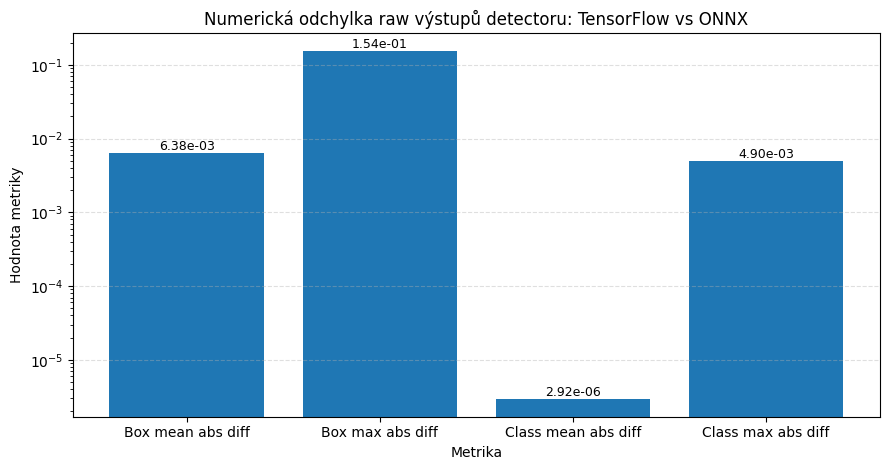

Saved: /workspace/models/reports/detector_raw_diff_metrics.png


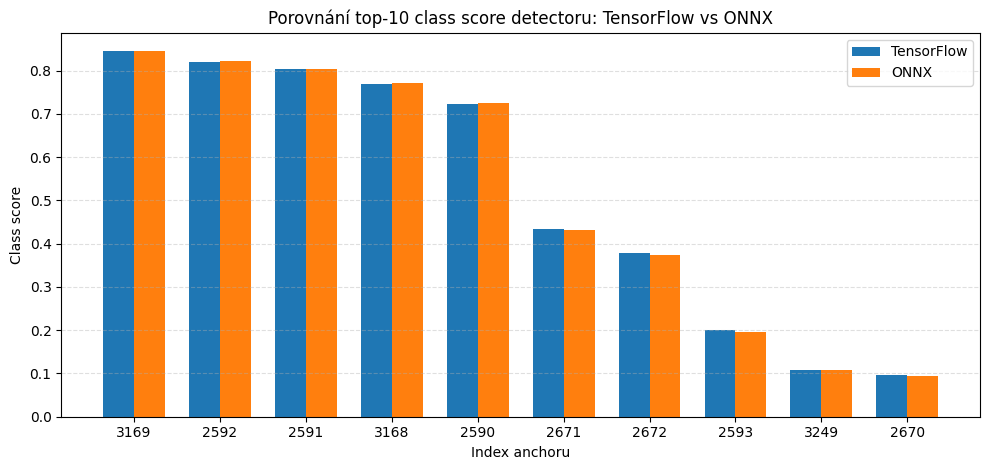

Saved: /workspace/models/reports/detector_top10_scores_tf_vs_onnx.png


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CHECK
# =========================================================
required_vars = [
    "box_abs_diff",
    "class_abs_diff",
    "tf_scores",
    "onnx_scores",
    "tf_top_idx",
    "onnx_top_idx",
]
for var in required_vars:
    assert var in globals(), f"Missing variable: {var}. Run the comparison cell first."

# =========================================================
# METRICS
# =========================================================
metrics = {
    "Box mean abs diff": float(np.mean(box_abs_diff)),
    "Box max abs diff": float(np.max(box_abs_diff)),
    "Class mean abs diff": float(np.mean(class_abs_diff)),
    "Class max abs diff": float(np.max(class_abs_diff)),
}

metric_labels = list(metrics.keys())
metric_values = list(metrics.values())

print("=== SUMMARY ===")
for k, v in metrics.items():
    print(f"{k}: {v:.10f}")

common_top10 = len(set(tf_top_idx.tolist()) & set(onnx_top_idx.tolist()))
print("Common top-10 anchors:", f"{common_top10}/10")

# =========================================================
# FIGURE 1: ERROR METRICS
# =========================================================
plt.figure(figsize=(9, 4.8))
bars = plt.bar(metric_labels, metric_values)

plt.ylabel("Hodnota metriky")
plt.xlabel("Metrika")
plt.title("Numerická odchylka raw výstupů detectoru: TensorFlow vs ONNX")
plt.yscale("log")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for b, v in zip(bars, metric_values):
    plt.text(
        b.get_x() + b.get_width() / 2,
        v,
        f"{v:.2e}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

fig1_path = REPORTS_DIR / "detector_raw_diff_metrics.png"
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig1_path)

# =========================================================
# FIGURE 2: TOP-10 CLASS SCORES
# =========================================================
# vezmeme anchor pořadí podle TF, aby bylo srovnání konzistentní
top_idx = tf_top_idx[:10]
tf_top_scores = tf_scores[top_idx]
onnx_top_scores = onnx_scores[top_idx]

x = np.arange(len(top_idx))
width = 0.36

plt.figure(figsize=(10, 4.8))
plt.bar(x - width / 2, tf_top_scores, width, label="TensorFlow")
plt.bar(x + width / 2, onnx_top_scores, width, label="ONNX")

plt.xticks(x, [str(int(i)) for i in top_idx])
plt.xlabel("Index anchoru")
plt.ylabel("Class score")
plt.title("Porovnání top-10 class score detectoru: TensorFlow vs ONNX")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

fig2_path = REPORTS_DIR / "detector_top10_scores_tf_vs_onnx.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig2_path)